In [1]:
import pandas as pd
import yfinance as yf
import os

## Ejemplo: Machine learning y Pandas

In [2]:
iris = pd.read_csv("iris.csv")
iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
try:
    import sklearn
    print(f"scikit-learn version: {sklearn.__version__}")
except ImportError:
    print("scikit-learn is not installed")


scikit-learn version: 1.7.2


In [38]:
#!pip install scikit-learn

In [4]:
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()

df = iris
df['target'] = label_encoder.fit_transform(df['species'])
df.drop('species',inplace=True,axis=1)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test, Y_train,Y_test= train_test_split(df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']],
                                                 df['target'], random_state=0)

In [8]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(max_depth = 2, 
                             random_state = 0)
clf.fit(X_train, Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.8333333333333334, 'x[2] <= 4.95\ngini = 0.513\nsamples = 112\nvalue = [72, 28, 12]'),
 Text(0.25, 0.5, 'x[3] <= 1.65\ngini = 0.08\nsamples = 73\nvalue = [70, 2, 1]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.0\nsamples = 69\nvalue = [69, 0, 0]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.625\nsamples = 4\nvalue = [1, 2, 1]'),
 Text(0.75, 0.5, 'x[2] <= 5.45\ngini = 0.473\nsamples = 39\nvalue = [2, 26, 11]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.594\nsamples = 16\nvalue = [2, 6, 8]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.227\nsamples = 23\nvalue = [0, 20, 3]')]

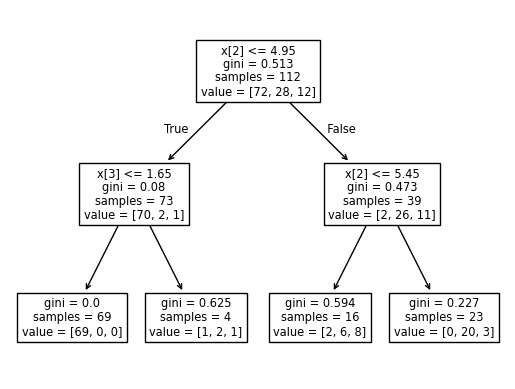

In [9]:
from sklearn import tree
import matplotlib.pyplot as plt

tree.plot_tree(clf)

[Text(0.5, 0.8333333333333334, 'petal length (cm) <= 4.95\ngini = 0.513\nsamples = 112\nvalue = [72, 28, 12]\nclass = setosa'),
 Text(0.25, 0.5, 'petal width (cm) <= 1.65\ngini = 0.08\nsamples = 73\nvalue = [70, 2, 1]\nclass = setosa'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.0\nsamples = 69\nvalue = [69, 0, 0]\nclass = setosa'),
 Text(0.375, 0.16666666666666666, 'gini = 0.625\nsamples = 4\nvalue = [1, 2, 1]\nclass = versicolor'),
 Text(0.75, 0.5, 'petal length (cm) <= 5.45\ngini = 0.473\nsamples = 39\nvalue = [2, 26, 11]\nclass = versicolor'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.594\nsamples = 16\nvalue = [2, 6, 8]\nclass = virginica'),
 Text(0.875, 0.16666666666666666, 'gini = 0.227\nsamples = 23\nvalue = [0, 20, 3]\nclass = versicolor')]

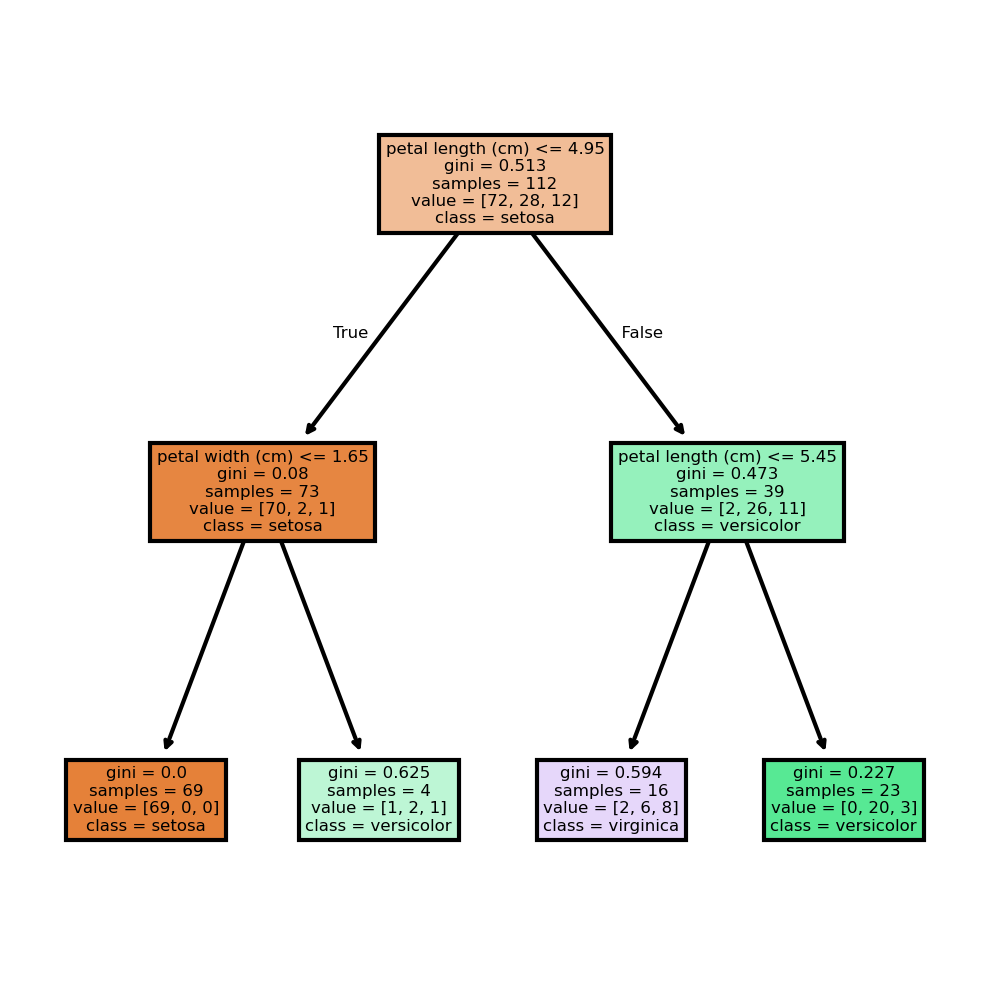

In [10]:
fn=['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']
cn=['setosa', 'versicolor', 'virginica']
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=300)
tree.plot_tree(clf,
               feature_names = fn, 
               class_names=cn,
               filled = True)

### Extrayendo elementos de una serie mediante las ETIQUETAS del índice

Usando el siguiente archivo `iris_id.csv`

In [11]:
import pandas as pd

In [12]:
iris_id = pd.read_csv('iris_id.csv', usecols = ['id', 'species'], index_col = 'id').squeeze()
iris_id.head()

id
A1    setosa
A2    setosa
A3    setosa
A4    setosa
A5    setosa
Name: species, dtype: object

In [13]:
iris_id

id
A1         setosa
A2         setosa
A3         setosa
A4         setosa
A5         setosa
          ...    
A146    virginica
A147    virginica
A148    virginica
A149    virginica
A150    virginica
Name: species, Length: 150, dtype: object

In [14]:
#quiero extraer el elemento que tiene el valor del índice igual a A15
iris_id['A15']

'setosa'

In [15]:
#tAMBIÉN podemos usar la sintaxis:
iris_id['A1':'A20']
#Cuando usamos ETIQUETAS del índice, el límite superior SÍ está incluido.

id
A1     setosa
A2     setosa
A3     setosa
A4     setosa
A5     setosa
A6     setosa
A7     setosa
A8     setosa
A9     setosa
A10    setosa
A11    setosa
A12    setosa
A13    setosa
A14    setosa
A15    setosa
A16    setosa
A17    setosa
A18    setosa
A19    setosa
A20    setosa
Name: species, dtype: object

In [16]:
iris_id['A1':'A20':2]  # serie[ini:fin: step]

id
A1     setosa
A3     setosa
A5     setosa
A7     setosa
A9     setosa
A11    setosa
A13    setosa
A15    setosa
A17    setosa
A19    setosa
Name: species, dtype: object

Método `.get()` sobre una Serie

In [17]:
iris_id.get(0)

C:\Users\kike2\AppData\Local\Temp\ipykernel_21724\956098991.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  iris_id.get(0)


'setosa'

In [18]:
iris_id.get('A20') #Equivalente a iris_id['A20']

'setosa'

In [19]:
iris_id[['A20']] #aquí sí me indica el índice

id
A20    setosa
Name: species, dtype: object

In [20]:
iris_id['A20'] #aquí sólo accedo al valor

'setosa'

In [21]:
#SI QUIERO MÁS DE UN ELEMENTO: LE PASO UNA LISTA
iris_id[['A3', 'A8', 'A20']]

id
A3     setosa
A8     setosa
A20    setosa
Name: species, dtype: object

In [22]:
iris_id.get(['A3', 'A8', 'A20'])

id
A3     setosa
A8     setosa
A20    setosa
Name: species, dtype: object

In [23]:
#IMPORTANTE: si alguna llave/índice no lo encuentra, get() NO REGRESA NADA
# Para ello podemos cambiar la condición default dentro del método:

In [24]:
iris_id.get('A200')

In [25]:
iris_id.tail()

id
A146    virginica
A147    virginica
A148    virginica
A149    virginica
A150    virginica
Name: species, dtype: object

In [26]:
iris_id.get(['A3', 'A7', 'A20'], default= 'ESTE ID NO EXISTE')

id
A3     setosa
A7     setosa
A20    setosa
Name: species, dtype: object

In [27]:
iris_id.get(['A3', 'A7', 'A200'], default = 'este id no existe')

'este id no existe'

In [28]:
# iris_id[['A3', 'A7', 'A200']] #error porque el A200 NO EXISTE

In [29]:
iris_id[-1:] #le estoy pidiendo el último elemento de la serie

id
A150    virginica
Name: species, dtype: object

In [30]:
# Notar que podemos modificar nuestra serie 'apple' para que tenga el índice numérico estándar usando 
# la función range()

In [31]:
range(1,5)

range(1, 5)

In [32]:
# Iterando de 0 a 4

for i in range(5):
    print(i)

0
1
2
3
4


In [33]:
for e in range(5): 
    print(e)

0
1
2
3
4


In [34]:
# Iterando de  1 a 4

for i in range(1,5):
    print(i)


1
2
3
4


In [35]:
list(range(5))

[0, 1, 2, 3, 4]

In [36]:
# iterar del 1 al 9, de 2 en 2:
for e in range(1,10,2):
    print(e)

1
3
5
7
9


In [37]:
for i in range(-1,-10,-1):
    print(i)

-1
-2
-3
-4
-5
-6
-7
-8
-9
